In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression # bibliothèque de référence en Python qui ontient des centaines d'algorithmes prêts à l'emploi pour la regression
from sklearn.metrics import mean_squared_error, r2_score

# Chargement des données
df = pd.read_csv('social_media_productivity_6000.csv')

# Nettoyage rapide (suppression des lignes avec des valeurs manquantes)
df = df.dropna()

In [7]:
# Sélection de plusieurs variables explicatives
X_multiple = df[['study_hours', 'social_media_hours', 'sleep_hours']]# définit les variables indépendantes pour la régression multiple( features)
y = df['productivity_score'] # définit le variable cible ( target)

# Création et entraînement
model_multiple = LinearRegression() # utiliser aussi pour la regression multiple
model_multiple.fit(X_multiple, y) # entrainement 

# Affichage des coefficients
coeff_df = pd.DataFrame(model_multiple.coef_, X_multiple.columns, columns=['Coefficient']) # C'est le passage des mathématiques brutes à un tableau clair
print("Influence de chaque variable :")
print(coeff_df)

print(f"\nR² Score (Multiple): {model_multiple.score(X_multiple, y):.4f}") # permet de mesurer la performance globale du modèle de Régression Multiple

Influence de chaque variable :
                    Coefficient
study_hours            8.825045
social_media_hours    -6.523108
sleep_hours            4.244465

R² Score (Multiple): 0.8528


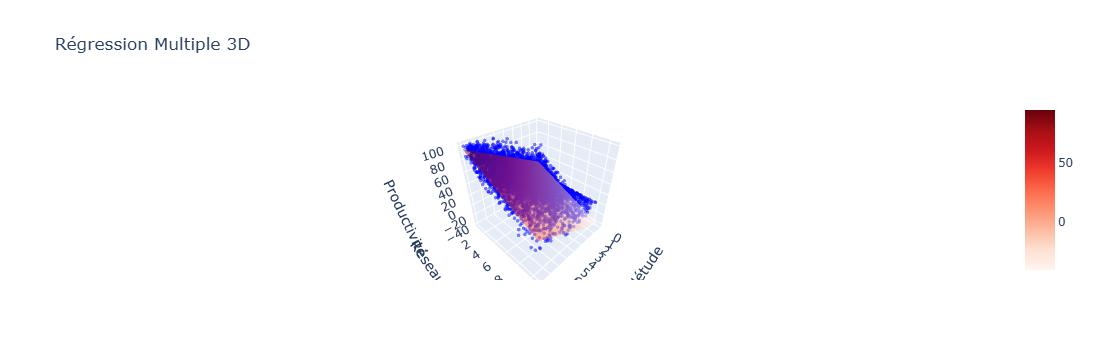

In [8]:
import plotly.express as px #une bibliothèque de visualisation de données moderne et interactive
import plotly.graph_objects as go # l'outil destiné à la précision chirurgicale

# 1. Préparation du modèle (si pas déjà fait)
X = df[['study_hours', 'social_media_hours']] # On en choisit 2 pour la 3D
y = df['productivity_score']
model = LinearRegression()
model.fit(X.values, y)

# 2. Création d'une grille pour le plan de régression
x_range = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 20) #crée une liste de valeurs régulièrement espacées pour l'axe des X (les heures d'étude)
y_range = np.linspace(df['social_media_hours'].min(), df['social_media_hours'].max(), 20) # pour l'axe des Y (les heures de réseaux sociaux)
x_grid, y_grid = np.meshgrid(x_range, y_range) # La fonction meshgrid(grille de mailles) prend vos deux listes de 20 points et les croise pour créer toutes les combinaisons possibles.

# Prédiction sur la grille
z_grid = model.predict(np.c_[x_grid.ravel(), y_grid.ravel()]).reshape(x_grid.shape) # culculation le score de productivité pour chaque point de la grille
 
# 3. Tracé avec Plotly (interactif dans Jupyter) la visualisation 3D finale
fig = emotional_fig = go.Figure(data=[
    # Nuage de points réels
    go.Scatter3d(x=df['study_hours'], y=df['social_media_hours'], z=df['productivity_score'],
                 mode='markers', marker=dict(size=2, opacity=0.5, color='blue'), name='Données réelles'),
    # Plan de régression
    go.Surface(x=x_range, y=y_range, z=z_grid, opacity=0.5, colorscale='Reds', name='Plan de prédiction')
])
# apres cette ligne le graphique passe d'un objet mathématique anonyme à un véritable outil de présentation professionnel
fig.update_layout(title='Régression Multiple 3D',
                  scene=dict(xaxis_title='Heures d\'étude',
                             yaxis_title='Réseaux Sociaux',
                             zaxis_title='Productivité'))
fig.show()

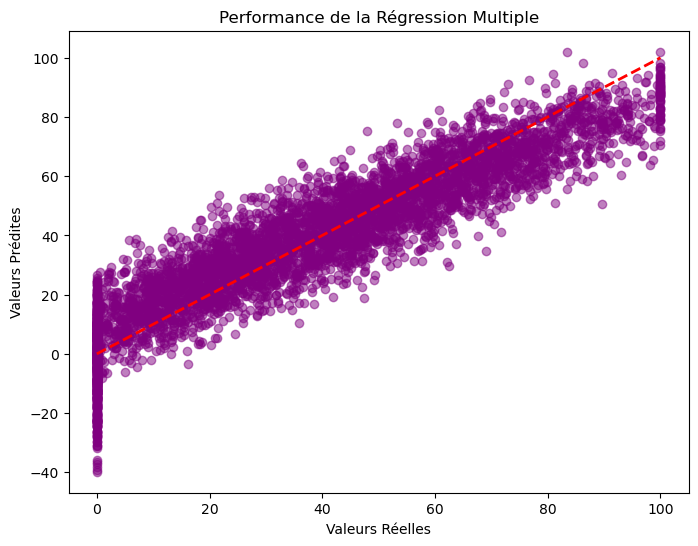

In [9]:
y_pred = model_multiple.predict(X_multiple)

plt.figure(figsize=(8, 6)) # une fenêtre de 8 pouces de large sur 6 pouces de haut ,c'est une taille standard qui permet de bien voir les détails sans que le graphique ne prenne tout l'écran
plt.scatter(y, y_pred, alpha=0.5, color='purple') # le cœur du diagnostic
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2) # Ligne de perfection
plt.xlabel('Valeurs Réelles')
plt.ylabel('Valeurs Prédites')
plt.title('Performance de la Régression Multiple')
plt.show()